In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("All libraries imported!")

All libraries imported!


In [4]:
df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\Applex\cleaned_ecommerce_data.csv')
print("Dataset loaded!")
print("Shape:", df.shape)
df.head()

Dataset loaded!
Shape: (1000, 23)


,Order_ID,Customer_ID,Customer_Name,Category,Sub_Category,Product_Name,Order_Date,Ship_Date,Region,City,...,Profit,Payment_Mode,Customer_Age,Rating,Order_Year,Order_Month,Order_Month_Name,Delivery_Days,Profit_Margin,Age_Group
0,ORD0001,CUST103,Vijay,Sports,Shirt,Mixer,2023-01-01 00:00:00,2023-01-03 00:00:00,North,Hyderabad,...,477.63,Net Banking,41.0,1.0,2023,1,January,2,18.69,Adult
1,ORD0002,CUST180,Deepa,Books,Shirt,Samsung TV,2023-01-01 08:00:00,2023-01-03 08:00:00,East,Mumbai,...,4415.49,COD,26.0,1.0,2023,1,January,2,37.96,Young Adult
2,ORD0003,CUST093,Sneha,Sports,Mobile,Python Book,2023-01-01 16:00:00,2023-01-03 16:00:00,North,Chennai,...,8819.19,UPI,32.0,4.0,2023,1,January,2,19.65,Young Adult
3,ORD0004,CUST015,Priya,Clothing,Novel,iPhone 14,2023-01-02 00:00:00,2023-01-04 00:00:00,North,Hyderabad,...,6233.29,Net Banking,52.0,5.0,2023,1,January,2,48.38,Senior
4,ORD0005,CUST107,Anita,Electronics,Shoes,Samsung TV,2023-01-02 08:00:00,2023-01-04 08:00:00,North,Delhi,...,3843.27,UPI,41.0,4.0,2023,1,January,2,34.59,Adult


In [5]:

print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
print(df.describe())

SUMMARY STATISTICS
              Sales     Quantity     Discount       Profit  Customer_Age  \
count   1000.000000  1000.000000  1000.000000  1000.000000   1000.000000   
mean   24877.971860     4.994000     0.144700  4875.553050     41.292000   
std    14351.194293     2.589337     0.112181  3037.091068     13.066655   
min      111.330000     1.000000     0.000000  -469.430000     18.000000   
25%    12688.740000     3.000000     0.000000  2374.165000     31.000000   
50%    24116.305000     5.000000     0.100000  4885.320000     41.000000   
75%    37517.352500     7.000000     0.200000  7529.377500     52.000000   
max    49939.770000     9.000000     0.300000  9981.460000     64.000000   

            Rating  Order_Year  Order_Month  Delivery_Days  Profit_Margin  
count  1000.000000      1000.0  1000.000000         1000.0    1000.000000  
mean      3.031000      2023.0     6.008000            2.0      62.530050  
std       1.402857         0.0     3.151487            0.0     310.6

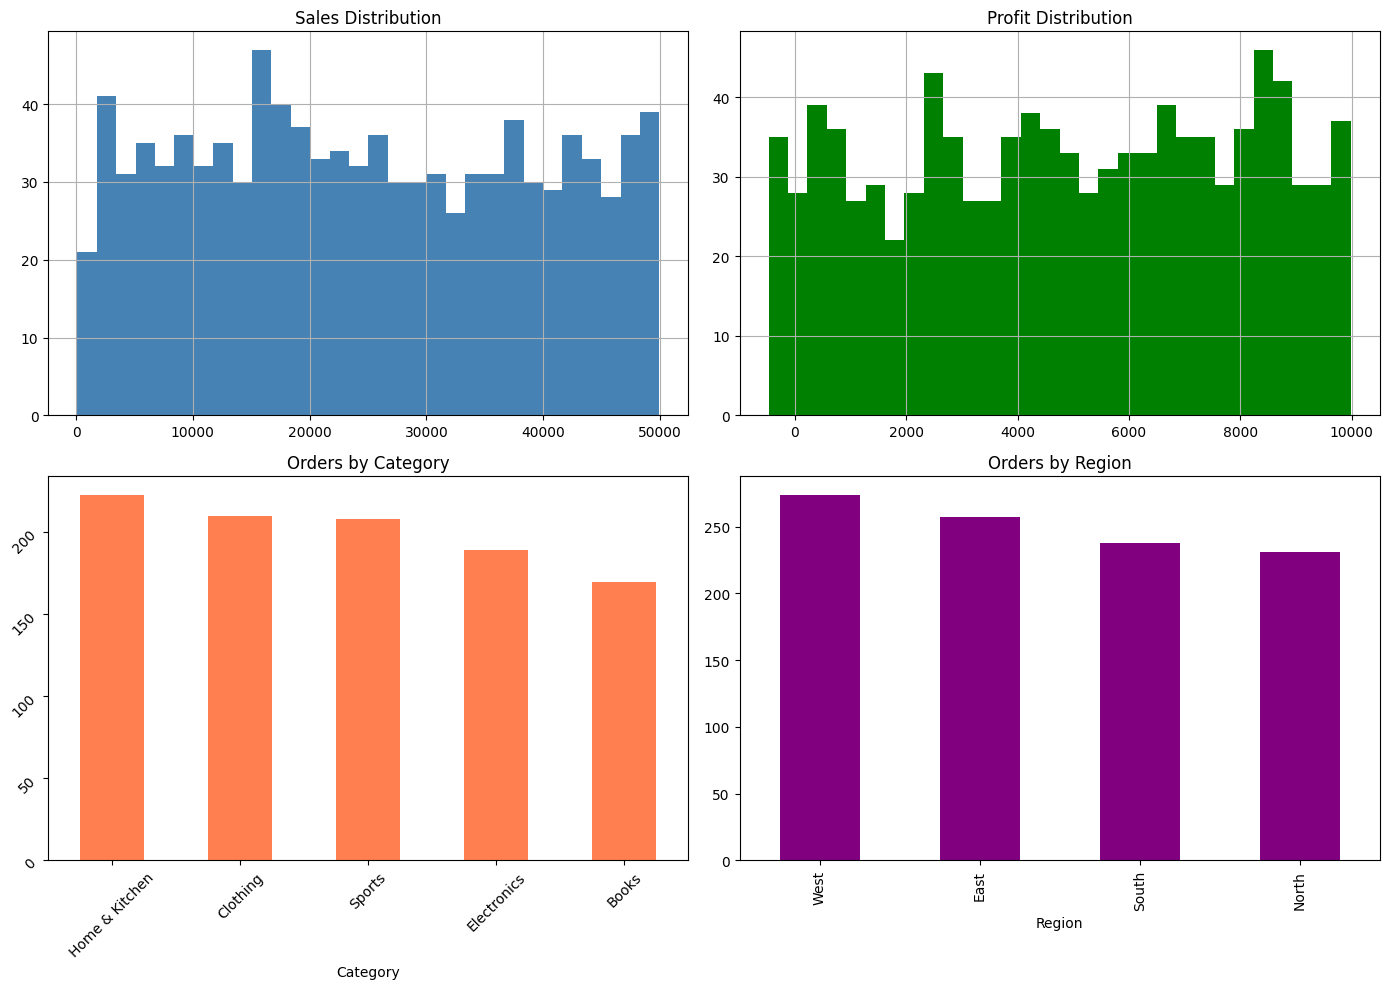

Univariate analysis done!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['Sales'].hist(bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Sales Distribution')

df['Profit'].hist(bins=30, ax=axes[0,1], color='green')
axes[0,1].set_title('Profit Distribution')

df['Category'].value_counts().plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Orders by Category')
axes[1,0].tick_params(rotation=45)

df['Region'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Orders by Region')

plt.tight_layout()
plt.savefig('task2_univariate.png')
plt.show()
print("Univariate analysis done!")

In [7]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales_data', conn, index=False, if_exists='replace')

# Q1: Top 5 products by revenue
q1 = pd.read_sql_query("""
    SELECT Product_Name, 
           ROUND(SUM(Sales), 2) as Total_Revenue
    FROM sales_data
    GROUP BY Product_Name
    ORDER BY Total_Revenue DESC
    LIMIT 5
""", conn)
print("Top 5 Products by Revenue:")
print(q1)

Top 5 Products by Revenue:
  Product_Name  Total_Revenue
0    iPhone 14     4576881.41
1  Dell Laptop     4284102.37
2  Python Book     4145314.07
3   Nike Shoes     4091284.95
4   Samsung TV     3941563.17


In [8]:
# Q2: Sales by Region
q2 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(SUM(Profit), 2) as Total_Profit,
           COUNT(*) as Total_Orders
    FROM sales_data
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)
print("Sales by Region:")
print(q2)

# Q3: Best Category
q3 = pd.read_sql_query("""
    SELECT Category,
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(AVG(Rating), 2) as Avg_Rating
    FROM sales_data
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", conn)
print("\nSales by Category:")
print(q3)

Sales by Region:
  Region  Total_Sales  Total_Profit  Total_Orders
0   West   6786930.67    1262929.51           274
1  South   6219704.59    1161719.08           238
2   East   6039133.08    1262247.84           257
3  North   5832203.52    1188656.62           231

Sales by Category:
         Category  Total_Sales  Avg_Rating
0  Home & Kitchen   5398858.47        3.03
1        Clothing   5383848.92        2.98
2          Sports   4966690.78        3.07
3     Electronics   4625563.23        3.12
4           Books   4503010.46        2.95


In [9]:
# Q4: Monthly Sales Trend
q4 = pd.read_sql_query("""
    SELECT Order_Month_Name,
           Order_Month,
           ROUND(SUM(Sales), 2) as Monthly_Sales
    FROM sales_data
    GROUP BY Order_Month
    ORDER BY Order_Month
""", conn)
print("Monthly Sales Trend:")
print(q4)

# Q5: Top Payment Mode
q5 = pd.read_sql_query("""
    SELECT Payment_Mode,
           COUNT(*) as Total_Orders,
           ROUND(SUM(Sales), 2) as Total_Sales
    FROM sales_data
    GROUP BY Payment_Mode
    ORDER BY Total_Orders DESC
""", conn)
print("\nOrders by Payment Mode:")
print(q5)

Monthly Sales Trend:
   Order_Month_Name  Order_Month  Monthly_Sales
0           January            1     2486357.11
1          February            2     2133370.70
2             March            3     2201835.39
3             April            4     2071361.86
4               May            5     2481892.19
5              June            6     2080111.97
6              July            7     2433273.67
7            August            8     2344209.96
8         September            9     2261750.53
9           October           10     2225000.87
10         November           11     2158807.61

Orders by Payment Mode:
  Payment_Mode  Total_Orders  Total_Sales
0          COD           254   5907443.76
1  Net Banking           251   6226907.41
2          UPI           249   6515112.55
3  Credit Card           246   6228508.14


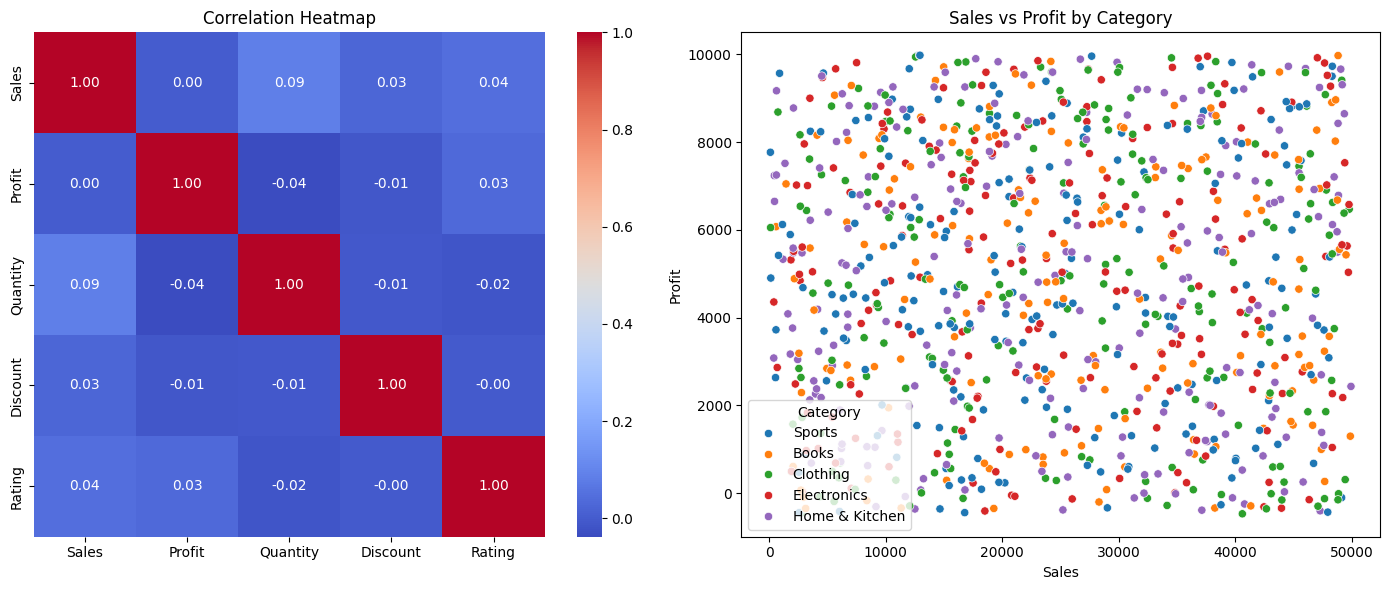

Multivariate analysis done!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
corr = df[['Sales','Profit','Quantity','Discount','Rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Correlation Heatmap')

# Scatter plot
sns.scatterplot(data=df, x='Sales', y='Profit', 
                hue='Category', ax=axes[1])
axes[1].set_title('Sales vs Profit by Category')

plt.tight_layout()
plt.savefig('task2_multivariate.png')
plt.show()
print("Multivariate analysis done!")

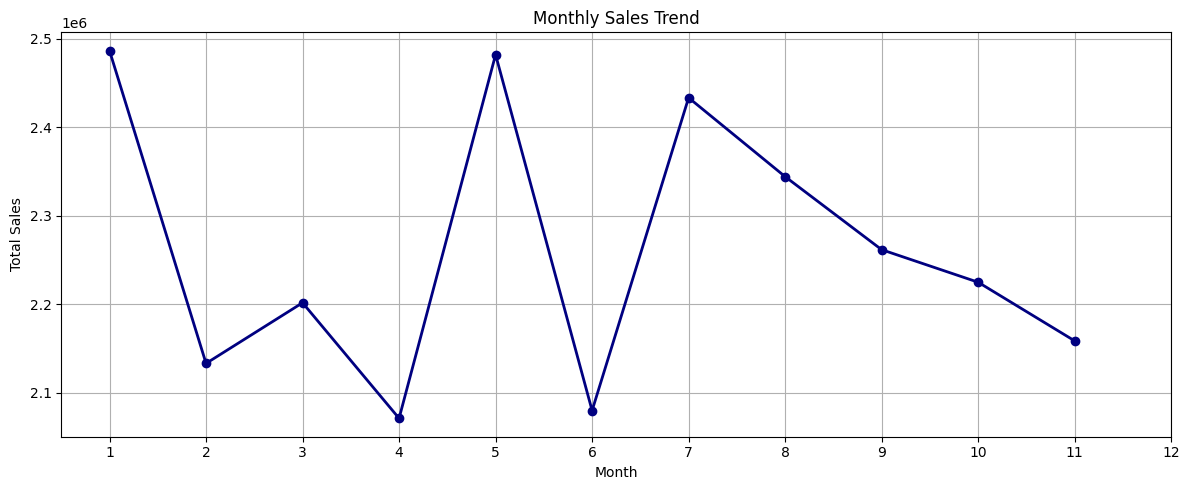

Monthly trend chart done!


In [11]:
monthly = df.groupby('Order_Month')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly['Order_Month'], monthly['Sales'], 
         marker='o', color='navy', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.savefig('task2_monthly_trend.png')
plt.show()
print("Monthly trend chart done!")

In [ ]:
print("=" * 50)
print("TASK 2 COMPLETE!")
print("=" * 50)
print("Files saved:")
print("  - task2_univariate.png")
print("  - task2_multivariate.png")
print("  - task2_monthly_trend.pngyes")
print("=" * 50)

TASK 2 COMPLETE!
Files saved:
  - task2_univariate.png
  - task2_multivariate.png
  - task2_monthly_trend.png
